<a href="https://colab.research.google.com/github/edwardmoreno18/redesNeuronales2/blob/main/06_MNIST_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Redes Neuronales II - Laboratorio F

## MNIST con PyTorch, sin CNN

**Objetivo:** replicar el problema de MNIST con una red densa **784 → 128 → 10**, haciendo explícito el ciclo de entrenamiento.

In [1]:

# ============================================
# LABORATORIO F - MNIST CON PYTORCH
# ============================================
# Utilizaremos la misma idea de arquitectura:
# 784 -> 128 -> 10
#
# PyTorch permite observar explícitamente el ciclo:
# 1. zero_grad()
# 2. forward
# 3. loss
# 4. backward()
# 5. optimizer.step()

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt


In [2]:
# ============================================
# CONFIGURAR DISPOSITIVO
# ============================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

# ============================================
# TRANSFORMACIÓN
# ============================================
# ToTensor convierte la imagen a tensor y normaliza
# los píxeles al intervalo [0, 1].

transform = transforms.ToTensor()

Dispositivo: cpu


In [3]:
# ============================================
# CARGAR MNIST
# ============================================
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.85MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 155kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.0MB/s]


In [4]:
# ============================================
# DATALOADERS
# ============================================
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Datos cargados correctamente.")

Datos cargados correctamente.


In [5]:
# ============================================
# DEFINIR LA RED
# ============================================
class RedMNIST(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()
        self.capa1 = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        self.salida = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.capa1(x)
        x = self.relu(x)
        x = self.salida(x)
        return x


modelo_pytorch = RedMNIST().to(device)

print(modelo_pytorch)

RedMNIST(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (capa1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (salida): Linear(in_features=128, out_features=10, bias=True)
)


In [6]:
# ============================================
# PÉRDIDA Y OPTIMIZADOR
# ============================================
# CrossEntropyLoss combina internamente una transformación
# apropiada para clasificación multiclase con el cálculo de pérdida.

criterio = nn.CrossEntropyLoss()

optimizador = optim.Adam(
    modelo_pytorch.parameters(),
    lr=0.001
)

In [7]:
# ============================================
# ENTRENAMIENTO
# ============================================
epochs = 3
loss_history_pytorch = []

for epoch in range(epochs):

    modelo_pytorch.train()
    error_total = 0.0

    for imagenes, etiquetas in train_loader:

        imagenes = imagenes.to(device)
        etiquetas = etiquetas.to(device)

        # 1. Limpiar gradientes anteriores
        optimizador.zero_grad()

        # 2. Forward
        salidas = modelo_pytorch(imagenes)

        # 3. Calcular loss
        error = criterio(salidas, etiquetas)

        # 4. Backpropagation
        error.backward()

        # 5. Actualizar pesos
        optimizador.step()

        error_total += error.item()

    promedio_error = error_total / len(train_loader)
    loss_history_pytorch.append(promedio_error)

    print(
        f"Época: {epoch + 1} | "
        f"Error promedio: {promedio_error:.4f}"
    )

Época: 1 | Error promedio: 0.3376
Época: 2 | Error promedio: 0.1571
Época: 3 | Error promedio: 0.1123


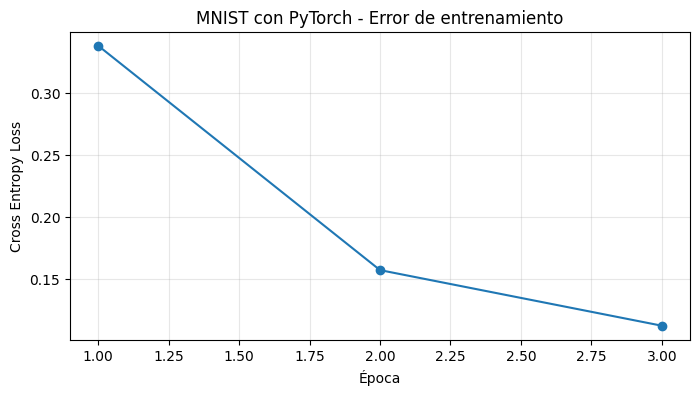

In [8]:
# ============================================
# GRÁFICA DEL LOSS
# ============================================
plt.figure(figsize=(8, 4))
plt.plot(
    range(1, epochs + 1),
    loss_history_pytorch,
    marker="o"
)
plt.title("MNIST con PyTorch - Error de entrenamiento")
plt.xlabel("Época")
plt.ylabel("Cross Entropy Loss")
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# ============================================
# EVALUACIÓN
# ============================================
modelo_pytorch.eval()

correctas = 0
total = 0

with torch.no_grad():

    for imagenes, etiquetas in test_loader:

        imagenes = imagenes.to(device)
        etiquetas = etiquetas.to(device)

        salidas = modelo_pytorch(imagenes)

        _, predicciones = torch.max(
            salidas,
            1
        )

        total += etiquetas.size(0)

        correctas += (
            predicciones == etiquetas
        ).sum().item()

accuracy_pytorch = correctas / total

print(f"Accuracy en prueba: {accuracy_pytorch:.4f}")

Accuracy en prueba: 0.9691


Número real: 7
Número predicho: 7


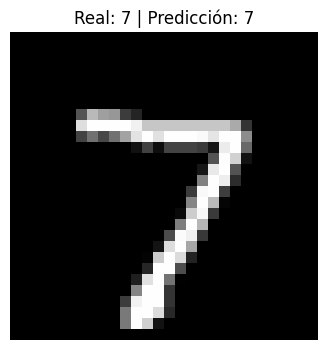

In [10]:
# ============================================
# PREDICCIÓN INDIVIDUAL
# ============================================
imagen, etiqueta_real = test_dataset[0]

entrada = imagen.unsqueeze(0).to(device)

modelo_pytorch.eval()

with torch.no_grad():
    salida = modelo_pytorch(entrada)
    prediccion = torch.argmax(
        salida,
        dim=1
    ).item()

print("Número real:", etiqueta_real)
print("Número predicho:", prediccion)

plt.figure(figsize=(4, 4))
plt.imshow(imagen.squeeze(), cmap="gray")
plt.title(
    f"Real: {etiqueta_real} | "
    f"Predicción: {prediccion}"
)
plt.axis("off")
plt.show()

### Punto clave
PyTorch hace visible el proceso: `zero_grad()` limpia gradientes, el forward produce salidas, `loss.backward()` calcula gradientes y `optimizer.step()` actualiza los pesos.